
# Notebook 02 - Train PPO và đánh giá mô hình

Notebook này sẽ dùng file `workload_real.csv` từ notebook 1 để:

1. đọc workload
2. tạo môi trường RL
3. train PPO
4. so sánh với baseline
5. lưu bảng kết quả và biểu đồ

## Nhắc lại mục tiêu đề tài
Ta muốn agent học cách:
- bật thêm host khi tải cao
- cho host ngủ khi tải thấp
- tăng/giảm DVFS
- để **giảm năng lượng** nhưng vẫn **giữ SLA ổn**


In [1]:

# Nếu thiếu thư viện thì bỏ comment và chạy 1 lần:
!pip install gymnasium stable-baselines3 tensorboard tqdm rich pandas matplotlib


In [2]:
import os
import sys
from pathlib import Path
import importlib.util
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.energy_env import CloudEnergyEnv, EnvConfig, load_workload_csv
from src.baselines import (
    FixedPolicy,
    RoundRobinPolicy,
    ThresholdPolicy,
    BestFitPolicy,
    run_policy,
)
from src.evaluation import save_trace_artifacts

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = D:\NT549.Q21-DRL-ERM-Cloud\azure_drl_beginner_project\azure_drl_beginner_project



## Bước 1 - Khai báo đường dẫn file workload

Nếu notebook 1 chạy xong đúng, file này đã nằm sẵn trong `data/`.


In [3]:

WORKLOAD_PATH = PROJECT_ROOT / "data" / "workload_real.csv"
WORKLOAD_PATH


WindowsPath('D:/NT549.Q21-DRL-ERM-Cloud/azure_drl_beginner_project/azure_drl_beginner_project/data/workload_real.csv')

In [4]:

if not WORKLOAD_PATH.exists():
    raise FileNotFoundError(
        f"Không thấy file {WORKLOAD_PATH}. Hãy chạy notebook 01 trước."
    )



## Bước 2 - Đọc workload và xem nhanh dữ liệu


In [5]:

workload_df = pd.read_csv(WORKLOAD_PATH)
display(workload_df.head())
display(workload_df.describe())


,timestep,demand,raw_core_demand,active_vm_count
0,0,0.989552,113390.769344,875495
1,1,0.988060,113219.745314,875378
2,2,0.985733,112953.144655,874422
3,3,0.984784,112844.379743,870308
4,4,0.987856,113196.421713,871064


,timestep,demand,raw_core_demand,active_vm_count
count,720.000000,720.000000,720.000000,720.000000
mean,359.500000,0.885871,101510.132917,793495.206944
std,207.990384,0.064989,7446.923959,62652.022796
min,0.000000,0.789629,90482.014597,695993.000000
25%,179.750000,0.826326,94687.048647,729997.500000
50%,359.500000,0.880510,100895.873880,793957.500000
75%,539.250000,0.925099,106005.191502,852517.000000
max,719.000000,1.022893,117211.225609,901284.000000



## Bước 3 - Vẽ lại demand để chắc chắn đầu vào ổn


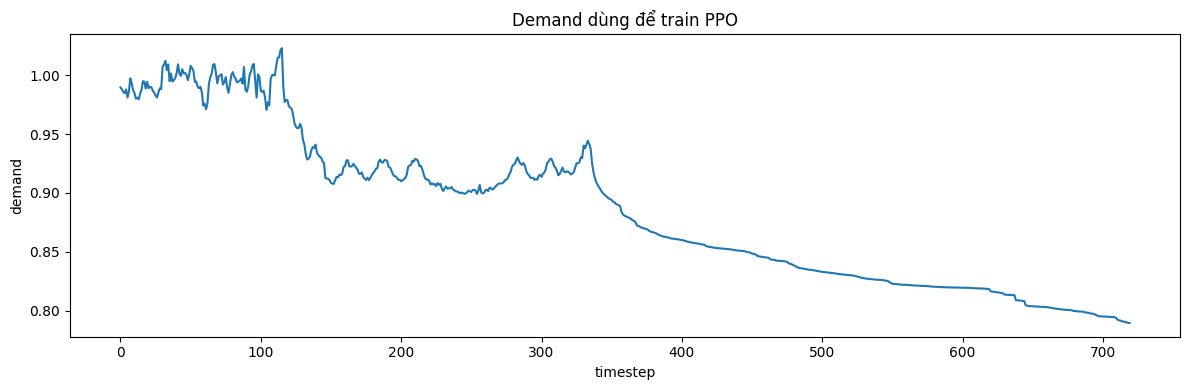

In [6]:

plt.figure(figsize=(12, 4))
plt.plot(workload_df["timestep"], workload_df["demand"])
plt.title("Demand dùng để train PPO")
plt.xlabel("timestep")
plt.ylabel("demand")
plt.tight_layout()
plt.show()



## Bước 4 - Tạo environment config

### Giải thích ngắn:
- `max_hosts`: cụm có tối đa bao nhiêu host
- `dvfs_levels`: các mức DVFS cho host
- `p_idle`, `p_peak`, `p_sleep`: power model
- `reward_w_energy`, `reward_w_sla`, `reward_w_switch`, `reward_w_util`: trọng số reward

> Lưu ý: nếu PPO chưa tiết kiệm điện tốt, thường bạn sẽ chỉnh chính các trọng số reward này.


In [ ]:
workload = load_workload_csv(str(WORKLOAD_PATH))

train_episode_length = 320
eval_episode_length = len(workload) - 1

train_config = EnvConfig(
    max_hosts=8,
    min_active_hosts=1,
    min_sleep_hosts=0,
    episode_length=train_episode_length,
    dvfs_levels=(0.6, 0.8, 1.0, 1.2),
    host_nominal_capacity=1.0 / 7.0,

    p_idle=80.0,
    p_peak=200.0,
    p_sleep=10.0,
    p_off=0.3,
    host_switch_cost=5.0,
    migration_cost=0.8,

    reward_w_energy=1.80,
    reward_w_sla=5.20,
    reward_w_switch=0.05,
    reward_w_migration=0.03,
    reward_w_util=0.10,
    reward_w_temp=0.08,
    reward_w_lifetime=0.03,
    reward_w_overprovision=1.10,
    reward_w_active_excess=1.00,
    reward_w_sleep_excess=0.18,
    reward_w_off_bonus=0.20,

    target_host_util=1.00,
    reserve_sleep_hosts=0,

    vm_unit_demand=0.10,
    seed=42,
)

eval_config = replace(train_config, episode_length=eval_episode_length, seed=42)

print("train_episode_length =", train_episode_length)
print("eval_episode_length  =", eval_episode_length)
print(train_config)

train_episode_length = 320
eval_episode_length  = 719
EnvConfig(max_hosts=8, min_active_hosts=1, min_sleep_hosts=1, episode_length=320, dvfs_levels=(0.6, 0.8, 1.0, 1.2), host_nominal_capacity=0.14285714285714285, p_idle=80.0, p_peak=200.0, p_sleep=10.0, p_off=0.3, host_switch_cost=5.0, migration_cost=0.8, reward_w_energy=1.8, reward_w_sla=5.2, reward_w_switch=0.05, reward_w_migration=0.03, reward_w_util=0.1, reward_w_temp=0.08, reward_w_lifetime=0.03, reward_w_overprovision=1.1, reward_w_active_excess=1.0, reward_w_sleep_excess=0.18, reward_w_off_bonus=0.2, target_host_util=1.0, reserve_sleep_hosts=0, base_pue=1.18, cooling_alpha=0.08, cooling_beta=0.18, cooling_fixed_power=25.0, ambient_temp_c=24.0, temp_idle_c=33.0, temp_rise_per_util=30.0, temp_rise_per_dvfs=10.0, temp_smoothing=0.3, reference_temp_c=35.0, max_safe_temp_c=80.0, aging_temp_threshold_c=45.0, aging_per_step_base=1.0, aging_temp_factor=0.03, vm_unit_demand=0.1, seed=42)



## Bước 5 - Test environment trước khi train
Nếu cell này chạy ổn thì environment của bạn hợp lệ.


In [8]:
env = CloudEnergyEnv(workload=workload, config=train_config)
check_env(env, warn=True)
print("Environment hợp lệ.")

Environment hợp lệ.



## Bước 6 - Chạy thử vài bước để hiểu agent đang nhìn thấy gì

Ở đây:
- `obs` là state
- `action` là quyết định
- `reward` là thưởng/phạt
- `info` là thông tin chi tiết ở từng bước


In [9]:

obs, _ = env.reset(seed=42)
print("obs ban đầu =", obs)

for step in range(3):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {step + 1}")
    print("action =", action)
    print("reward =", reward)
    print("info =", info)


obs ban đầu = [9.9480277e-01 1.0013679e+00 8.7500000e-01 8.3333331e-01 6.4754903e-01
 0.0000000e+00 1.4211468e-01 1.0443256e-01 1.2500000e-01 0.0000000e+00
 4.2195916e-01 4.1734928e-01 1.0000000e-03 0.0000000e+00]

Step 1
action = 6
reward = -1.1265677172865947
info = {'demand': 0.9948027729988098, 'power_it': 1191.3804931640625, 'power': 1557.807988410488, 'power_total': 1557.807988410488, 'pue': 1.3075654648946526, 'sla_violation': 0.0, 'active_hosts': 7, 'sleep_hosts': 1, 'off_hosts': 0, 'dvfs': 1.0, 'mean_util': 0.8111674189567566, 'switches': 0, 'wake_from_off': 0, 'migrations': 0, 'avg_temp': 39.959503173828125, 'max_temp': 45.93000030517578, 'thermal_penalty': 0.110211181640625, 'lifetime_penalty': 0.027900009155273464, 'mean_host_age': 2.0034875869750977, 'sla': 0.0, 'spare_ratio': 0.0051972270011901855, 'overprovision_penalty': 0.0, 'migration_plan': [], 'cooling_power': 366.42749524642545, 'host_loads': [0.3979211151599884, 0.0994802787899971, 0.0994802787899971, 0.0994802787


## Bước 7 - Tạo hàm build environment cho PPO


In [10]:
def make_env():
    return Monitor(CloudEnergyEnv(workload=workload, config=train_config))


## Bước 8 - Khai báo tham số train
- `TOTAL_TIMESTEPS` càng lớn thì agent có nhiều cơ hội học hơn
- khi mới chạy thử, bạn có thể để 60,000
- muốn kết quả tốt hơn thì có thể tăng lên 200,000 hoặc hơn


In [11]:
MODEL_PATH = PROJECT_ROOT / "outputs" / "ppo_cloud_energy_from_real_workload"
RESULT_CSV = PROJECT_ROOT / "outputs" / "evaluation_results_real_workload.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TB_LOG_DIR = OUTPUT_DIR / "tb_logs"

TRAIN_FROM_SCRATCH = True
TOTAL_TIMESTEPS = 400_000
N_ENVS = 2

MODEL_PATH, RESULT_CSV, OUTPUT_DIR

(WindowsPath('D:/NT549.Q21-DRL-ERM-Cloud/azure_drl_beginner_project/azure_drl_beginner_project/outputs/ppo_cloud_energy_from_real_workload'),
 WindowsPath('D:/NT549.Q21-DRL-ERM-Cloud/azure_drl_beginner_project/azure_drl_beginner_project/outputs/evaluation_results_real_workload.csv'),
 WindowsPath('D:/NT549.Q21-DRL-ERM-Cloud/azure_drl_beginner_project/azure_drl_beginner_project/outputs'))


## Bước 9 - Train PPO
Nếu máy bạn chưa có tensorboard hoặc progress bar đẹp, code vẫn train bình thường.


In [12]:
policy_kwargs = dict(
    net_arch=dict(pi=[128, 128], vf=[128, 128])
)

if TRAIN_FROM_SCRATCH:
    vec_env = DummyVecEnv([make_env for _ in range(N_ENVS)])

    model = PPO(
        policy="MlpPolicy",
        env=vec_env,
        learning_rate=7e-5,
        n_steps=2048,
        batch_size=512,
        n_epochs=10,
        gamma=0.997,
        gae_lambda=0.98,
        clip_range=0.15,
        ent_coef=0.010,
        vf_coef=0.70,
        max_grad_norm=0.5,
        target_kl=0.02,
        policy_kwargs=policy_kwargs,
        verbose=1,
        seed=42,
        device="cpu",
        tensorboard_log=str(TB_LOG_DIR),
    )

    model.learn(total_timesteps=TOTAL_TIMESTEPS)
    model.save(str(MODEL_PATH))
    vec_env.close()

    print("Đã train và lưu model tại:", str(MODEL_PATH) + ".zip")
else:
    model = PPO.load(str(MODEL_PATH) + ".zip", device="cpu")
    print("Đã load model tại:", str(MODEL_PATH) + ".zip")

Using cpu device
Logging to D:\NT549.Q21-DRL-ERM-Cloud\azure_drl_beginner_project\azure_drl_beginner_project\outputs\tb_logs\PPO_12
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 320       |
|    ep_rew_mean     | -2.38e+03 |
| time/              |           |
|    fps             | 1030      |
|    iterations      | 1         |
|    time_elapsed    | 3         |
|    total_timesteps | 4096      |
----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 320           |
|    ep_rew_mean          | -2.22e+03     |
| time/                   |               |
|    fps                  | 994           |
|    iterations           | 2             |
|    time_elapsed         | 8             |
|    total_timesteps      | 8192          |
| train/                  |               |
|    approx_kl            | 0.00019222386 |
|    clip_fraction        | 0     


## Bước 10 - Chạy baseline và PPO để đánh giá

Ta sẽ so sánh:
- Fixed-Keep
- Threshold
- BestFitLike
- PPO

> Lưu ý: `BestFitLike` ở đây là heuristic xấp xỉ Best Fit ở mức **cluster-level**,  
không phải placement VM chi tiết từng server.


In [13]:
test_env = CloudEnergyEnv(workload=workload, config=eval_config)
obs, _ = test_env.reset(seed=42)

actions = []
for _ in range(20):
    action, _ = model.predict(obs, deterministic=True)
    action = int(np.asarray(action).item())
    actions.append(action)
    obs, reward, terminated, truncated, info = test_env.step(action)
    if terminated or truncated:
        break

print(actions)

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


In [14]:
def evaluate_once(policy_name: str, policy, workload, config):
    env_local = CloudEnergyEnv(workload=workload, config=config)
    metrics = run_policy(env_local, policy)
    return env_local, {
        "policy": policy_name,
        "total_reward": metrics.total_reward,
        "total_energy": metrics.total_energy,
        "total_it_energy": metrics.total_it_energy,
        "avg_power": metrics.avg_power,
        "avg_pue": metrics.avg_pue,
        "sla_rate": metrics.sla_rate,
        "avg_active_hosts": metrics.avg_active_hosts,
        "avg_sleep_hosts": metrics.avg_sleep_hosts,
        "avg_off_hosts": metrics.avg_off_hosts,
        "avg_temp": metrics.avg_temp,
        "total_switches": metrics.total_switches,
        "total_migrations": metrics.total_migrations,
    }

rows = []

fixed_env, fixed_row = evaluate_once("Fixed-Keep", FixedPolicy(0), workload, eval_config)
rows.append(fixed_row)

rr_env, rr_row = evaluate_once("RoundRobin", RoundRobinPolicy(), workload, eval_config)
rows.append(rr_row)

th_env, th_row = evaluate_once("Threshold", ThresholdPolicy(), workload, eval_config)
rows.append(th_row)

bf_env, bf_row = evaluate_once("BestFit", BestFitPolicy(), workload, eval_config)
rows.append(bf_row)

loaded_model = PPO.load(str(MODEL_PATH) + ".zip", device="cpu")
ppo_env, ppo_row = evaluate_once("PPO", loaded_model, workload, eval_config)
rows.append(ppo_row)

# lưu trace cho các policy quan trọng
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
save_trace_artifacts(rr_env.trace, OUTPUT_DIR, prefix="round_robin")
save_trace_artifacts(ppo_env.trace, OUTPUT_DIR, prefix="ppo")

results_df = pd.DataFrame(rows)

# sắp xếp để đọc dễ hơn
results_df = results_df.sort_values(
    by=["total_reward", "sla_rate", "total_energy"],
    ascending=[False, True, True]
).reset_index(drop=True)

# lưu CSV ngay tại đây để notebook và file ngoài luôn đồng bộ
results_df.to_csv(RESULT_CSV, index=False)

print("Đã lưu kết quả tại:", RESULT_CSV)
display(results_df)

best_reward_policy = results_df.loc[0, "policy"]
best_energy_policy = results_df.sort_values("total_energy", ascending=True).iloc[0]["policy"]
best_sla_policy = results_df.sort_values("sla_rate", ascending=True).iloc[0]["policy"]

print(f"Policy đứng đầu theo total_reward: {best_reward_policy}")
print(f"Policy tiết kiệm năng lượng nhất: {best_energy_policy}")
print(f"Policy ít vi phạm SLA nhất: {best_sla_policy}")

print("\nLưu ý khi viết báo cáo:")
print("- Không nhìn mỗi total_energy.")
print("- Không mặc định PPO thắng toàn diện.")
print("- Phải đọc trade-off giữa total_reward, sla_rate và total_energy.")

Đã lưu kết quả tại: D:\NT549.Q21-DRL-ERM-Cloud\azure_drl_beginner_project\azure_drl_beginner_project\outputs\evaluation_results_real_workload.csv


,policy,total_reward,total_energy,total_it_energy,avg_power,avg_pue,sla_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_temp,total_switches,total_migrations
0,Fixed-Keep,-972.711864,1.171390e+06,8.355204e+05,1629.193225,1.401942,0.000298,7.0,1.0,0.0,54.306008,0,0
1,Threshold,-1256.105527,1.313174e+06,9.409606e+05,1826.389080,1.395526,0.000000,8.0,0.0,0.0,57.817954,1,1
2,BestFit,-1256.105527,1.313174e+06,9.409606e+05,1826.389080,1.395526,0.000000,8.0,0.0,0.0,57.817954,1,1
3,PPO,-1281.952057,1.305747e+06,9.413657e+05,1816.059506,1.387042,0.000000,7.0,1.0,0.0,53.600107,0,0
4,RoundRobin,-1511.533435,1.427081e+06,1.032439e+06,1984.813216,1.382541,0.000000,8.0,0.0,0.0,57.122596,1,1


Policy đứng đầu theo total_reward: Fixed-Keep
Policy tiết kiệm năng lượng nhất: Fixed-Keep
Policy ít vi phạm SLA nhất: Threshold

Lưu ý khi viết báo cáo:
- Không nhìn mỗi total_energy.
- Không mặc định PPO thắng toàn diện.
- Phải đọc trade-off giữa total_reward, sla_rate và total_energy.



## Bước 11 - Lưu bảng kết quả ra CSV


In [15]:
if not RESULT_CSV.exists():
    raise FileNotFoundError(f"Không thấy file kết quả: {RESULT_CSV}")

results_check = pd.read_csv(RESULT_CSV)
display(results_check)
print("Notebook và file CSV đã đồng bộ.")

,policy,total_reward,total_energy,total_it_energy,avg_power,avg_pue,sla_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_temp,total_switches,total_migrations
0,Fixed-Keep,-972.711864,1.171390e+06,8.355204e+05,1629.193225,1.401942,0.000298,7.0,1.0,0.0,54.306008,0,0
1,Threshold,-1256.105527,1.313174e+06,9.409606e+05,1826.389080,1.395526,0.000000,8.0,0.0,0.0,57.817954,1,1
2,BestFit,-1256.105527,1.313174e+06,9.409606e+05,1826.389080,1.395526,0.000000,8.0,0.0,0.0,57.817954,1,1
3,PPO,-1281.952057,1.305747e+06,9.413657e+05,1816.059506,1.387042,0.000000,7.0,1.0,0.0,53.600107,0,0
4,RoundRobin,-1511.533435,1.427081e+06,1.032439e+06,1984.813216,1.382541,0.000000,8.0,0.0,0.0,57.122596,1,1


Notebook và file CSV đã đồng bộ.



## Bước 12 - Vẽ biểu đồ so sánh năng lượng
Cột càng thấp thì càng tiết kiệm điện hơn.


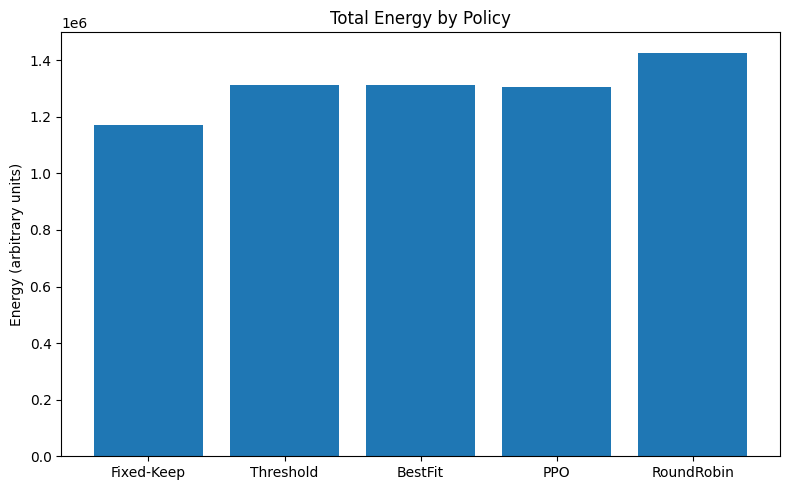

In [16]:

plt.figure(figsize=(8, 5))
plt.bar(results_df["policy"], results_df["total_energy"])
plt.title("Total Energy by Policy")
plt.ylabel("Energy (arbitrary units)")
plt.tight_layout()
plt.show()



## Bước 13 - Vẽ biểu đồ so sánh SLA
Cột càng thấp thì càng ít vi phạm SLA.


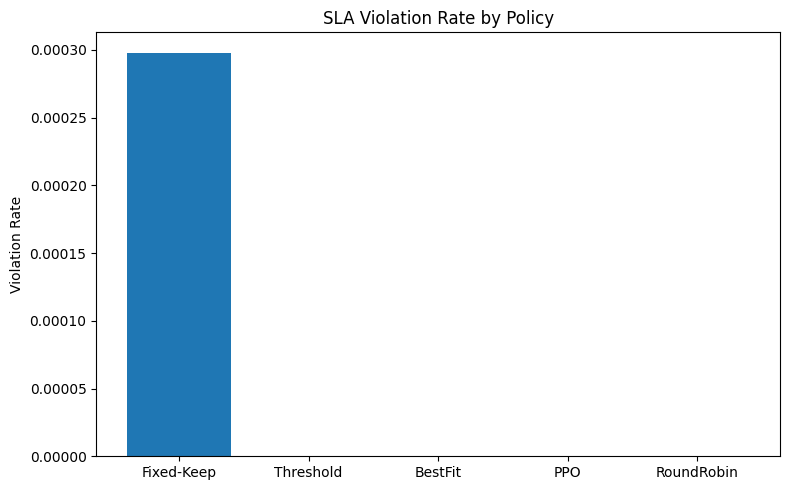

In [17]:

plt.figure(figsize=(8, 5))
plt.bar(results_df["policy"], results_df["sla_rate"])
plt.title("SLA Violation Rate by Policy")
plt.ylabel("Violation Rate")
plt.tight_layout()
plt.show()



## Bước 14 - Kết luận nhanh từ kết quả

Cách đọc:
- `total_energy` thấp hơn -> tiết kiệm điện hơn
- `sla_rate` thấp hơn -> ít quá tải hơn
- `avg_active_hosts` thấp hơn -> cụm dùng ít host hơn
- `total_switches` thấp hơn -> ít bật/tắt hơn

### Cẩn thận
Một policy có thể:
- tiết kiệm điện hơn
- nhưng lại vi phạm SLA nhiều hơn

Cho nên bạn không được nhìn mỗi `energy`, mà phải nhìn **trade-off giữa energy và SLA**.



## Bước 15 - Bạn nên làm gì tiếp theo sau khi chạy notebook này?

Nếu kết quả PPO chưa đẹp, bạn làm theo thứ tự này:

1. Tăng `TOTAL_TIMESTEPS`
2. Chỉnh reward:
   - tăng `reward_w_energy` nếu muốn tiết kiệm điện mạnh hơn
   - tăng `reward_w_sla` nếu muốn giảm vi phạm SLA mạnh hơn
3. Train nhiều lần với seed khác nhau
4. Lấy trung bình kết quả để đưa vào báo cáo

## Gợi ý viết báo cáo
Bạn có thể mô tả pipeline của nhóm như sau:

- Dữ liệu workload được trích xuất từ AzurePackingTraceV1 ở định dạng SQLite
- Từ bảng `vm` và `vmType`, nhóm xây dựng chuỗi nhu cầu tài nguyên theo thời gian
- Chuỗi này được chuẩn hóa thành `demand` để đưa vào môi trường DRL
- Môi trường mô phỏng trạng thái host, mức DVFS, power và SLA
- Tác nhân PPO học chính sách điều khiển tài nguyên nhằm cân bằng giữa tiết kiệm điện và đảm bảo SLA
